# Notebook 03 — Exploratory Data Analysis
Understand distributions, relationships, and patterns before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED = '../data/processed/'
proj  = pd.read_csv(PROCESSED + 'cleaned_project_level.csv',  low_memory=False)
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Project-level: ', proj.shape)
print('Disaster-level:', disas.shape)


Project-level:  (809734, 33)
Disaster-level: (1766, 20)


## 3.1 Target Distribution — Raw vs Log-Transformed
This plot justifies our decision to log-transform the target.


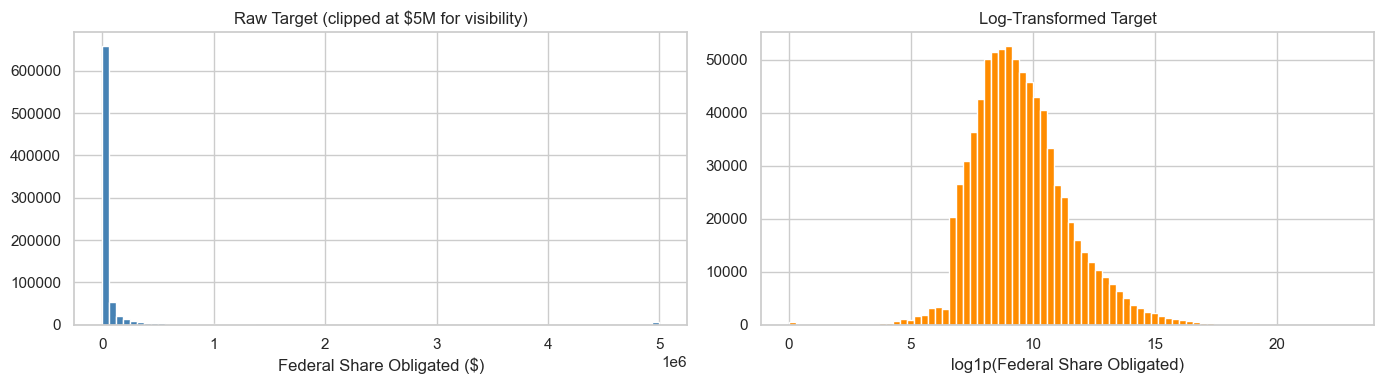

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(proj['federalShareObligated'].clip(upper=5e6), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Target (clipped at $5M for visibility)')
axes[0].set_xlabel('Federal Share Obligated ($)')

axes[1].hist(proj['log_federal_share'], bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Target')
axes[1].set_xlabel('log1p(Federal Share Obligated)')

plt.tight_layout()
plt.savefig('../data/processed/eda_target_distribution.png', dpi=150)
plt.show()


## 3.2 Mean Payout by Incident Type


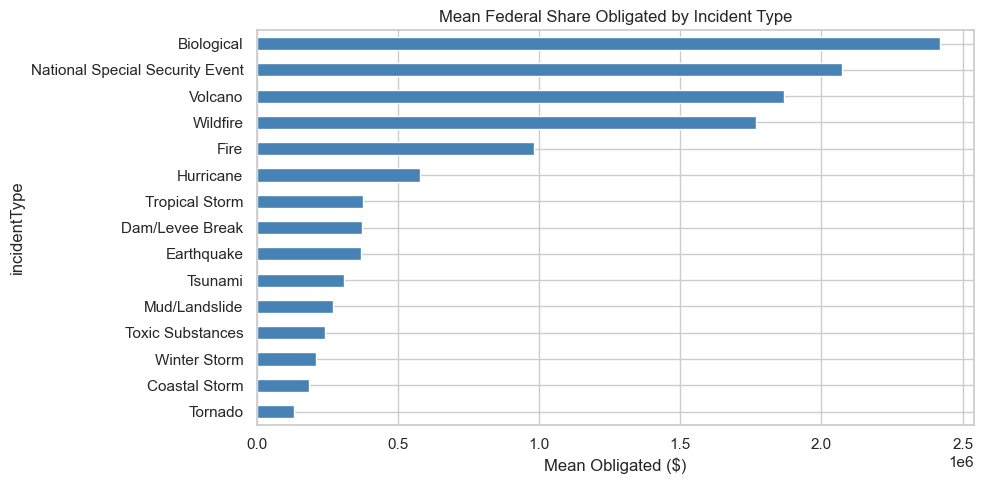

In [3]:
avg_by_type = (
    proj.groupby('incidentType')['federalShareObligated']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
avg_by_type.plot(kind='barh', figsize=(10, 5), color='steelblue',
                 title='Mean Federal Share Obligated by Incident Type')
plt.xlabel('Mean Obligated ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3.3 Mean Payout by Damage Category


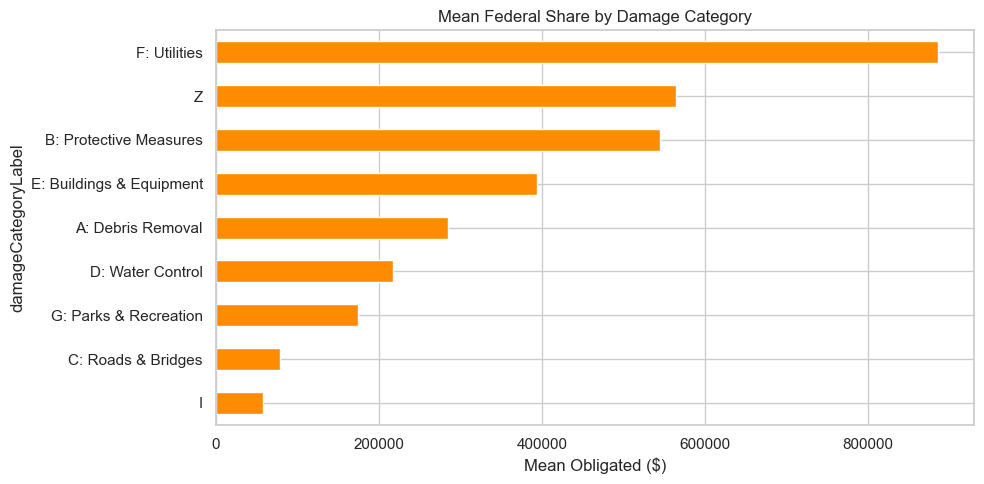

In [4]:
cat_labels = {
    'A': 'A: Debris Removal',
    'B': 'B: Protective Measures',
    'C': 'C: Roads & Bridges',
    'D': 'D: Water Control',
    'E': 'E: Buildings & Equipment',
    'F': 'F: Utilities',
    'G': 'G: Parks & Recreation'
}
proj['damageCategoryLabel'] = proj['damageCategoryCode'].map(cat_labels).fillna(proj['damageCategoryCode'])

avg_by_cat = (
    proj.groupby('damageCategoryLabel')['federalShareObligated']
    .mean()
    .sort_values(ascending=False)
)
avg_by_cat.plot(kind='barh', figsize=(10, 5), color='darkorange',
                title='Mean Federal Share by Damage Category')
plt.xlabel('Mean Obligated ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3.4 Total Federal Obligations by Year


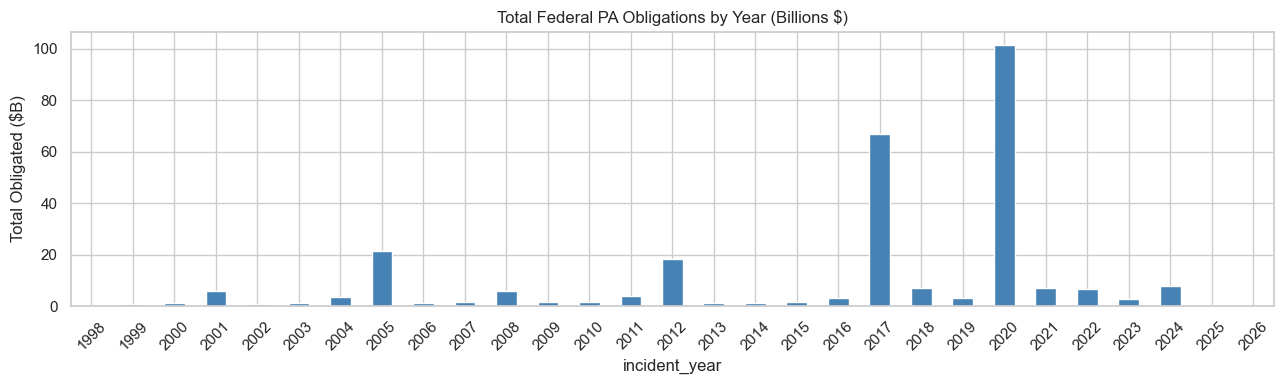

In [5]:
yearly = proj.groupby('incident_year')['federalShareObligated'].sum() / 1e9  # in billions
yearly.plot(kind='bar', figsize=(13, 4), color='steelblue', edgecolor='white',
            title='Total Federal PA Obligations by Year (Billions $)')
plt.ylabel('Total Obligated ($B)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3.5 Log Payout by Season


C:\Users\63429\AppData\Local\Temp\ipykernel_6864\423162472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=proj, x='incident_season', y='log_federal_share',


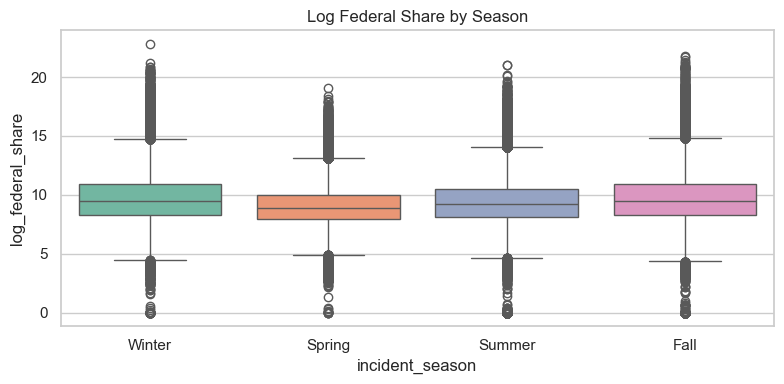

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=proj, x='incident_season', y='log_federal_share',
            order=['Winter', 'Spring', 'Summer', 'Fall'],
            palette='Set2')
plt.title('Log Federal Share by Season')
plt.tight_layout()
plt.show()


## 3.6 Correlation Heatmap (Numeric Features)


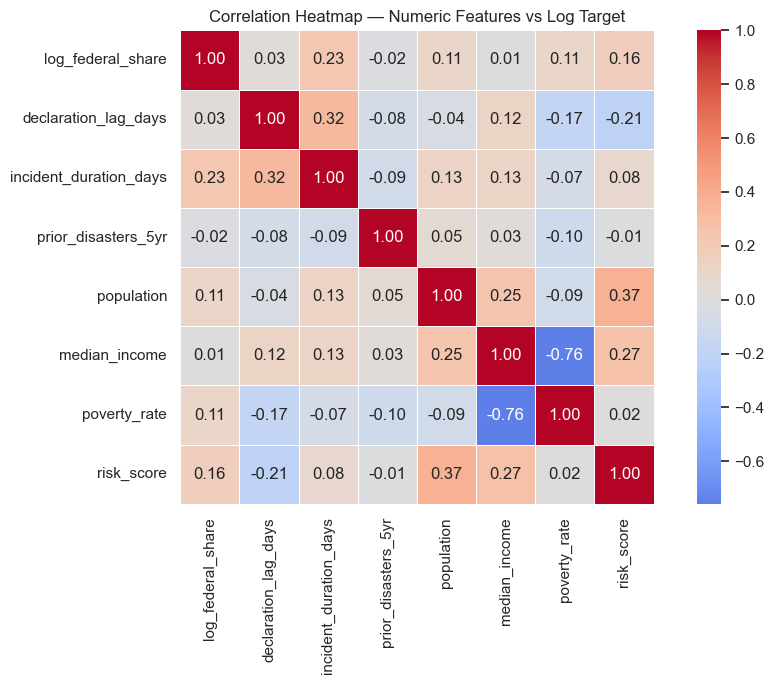

In [7]:
num_cols = ['log_federal_share', 'declaration_lag_days', 'incident_duration_days',
            'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']
num_cols = [c for c in num_cols if c in proj.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(proj[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features vs Log Target')
plt.tight_layout()
plt.show()


## 3.7 Top 10 States by Total Obligation


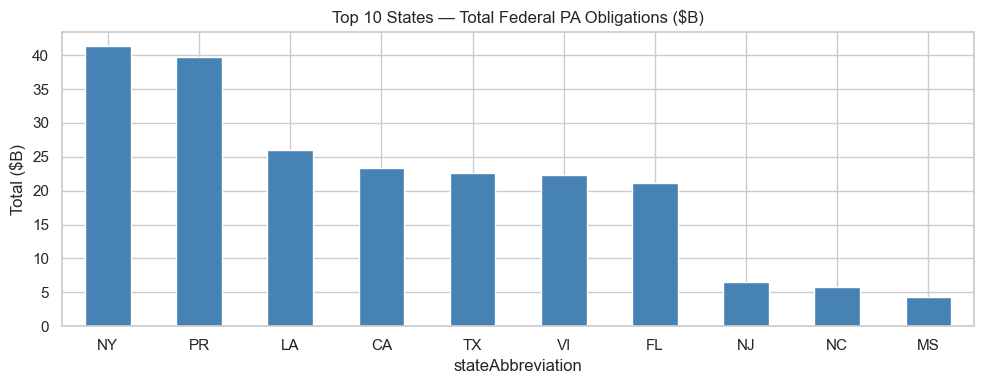

In [8]:
top_states = (
    proj.groupby('stateAbbreviation')['federalShareObligated']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    / 1e9
)
top_states.plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white',
                title='Top 10 States — Total Federal PA Obligations ($B)')
plt.ylabel('Total ($B)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3.8 Missing Data Summary


In [9]:
missing = proj.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print('Remaining nulls in project-level data:')
    print(missing)
else:
    print('No nulls remaining in project-level data. ')


Remaining nulls in project-level data:
risk_rating    25992
county         13614
applicantId        5
dtype: int64
